In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import sys
ROOT = Path.cwd().parent.parent
sys.path.append(str(ROOT))
from src.loading_data.load_data import get_data
from src.stream_3.gower_distance import get_gower
from sklearn.preprocessing import StandardScaler
import umap 
import umap.plot
import matplotlib.pyplot as plt
import hdbscan
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer
from sklearn.model_selection import GridSearchCV
from tqdm import tqdm
from src.stream_3.hdb_cluster_validation import hdb_dbcv
import seaborn as sns
from src.stream_3.gen_hdb_clus import GenerateHBDSCAN
from src.loading_data.data_catalogue import DataCatalogue
from src.stream_3.gower_distance import get_gower
from src.stream_3.gen_umap_emb import GenerateUmapEmb

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\numba\np\ufunc\dufunc.py:346: NumbaWarning: Compilation requested for previously compiled argument types ((uint32,)). This has no effect and perhaps indicates a bug in the calling code (compiling a ufunc more than once for the same signature
  warnings.warn(msg, errors.NumbaWarning)
c:\Users\fergu\Do

In [49]:
df = get_data()
categorical_cols = ['Gend3', 'Disab3',  'Eth7', 'WorkStat10', 'HHLiv12'] # VolAny is catgeorical but doesnt need to be encoded
continuous_cols = ['NSSEC5', 'IMD10', 'nchild', 'Motiva_POP', 'motivb_POP','motivc_POP', 'motivd_POP','Age9', 'Educ6']
drop_cols = ['year', 'active', 'MEMS7_ALL', 'LA_2023', 'LondInOut', 'LOG_MEMS7_ALL', 'VolAny', 'nadult']
df_2016 = df[df['year'] == '2016/17']
active, mems = df_2016['active'].values, df_2016['MEMS7_ALL'].values
cat_bool_mask = [True if c in categorical_cols else False for c in df_2016.columns]
df_2016_clean = df_2016.drop(columns=(drop_cols))
print(f'These are the cols: {df_2016_clean.columns}')
print(f'These are the categorical cols: {categorical_cols}')
gower_matrix = get_gower(categorical_cols, df_2016_clean)
emb = umap.UMAP(n_neighbors=10, metric = 'precomputed', random_state = 42).fit(gower_matrix)

c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['active'] = df['MEMS7_ALL'] >= 150
c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LOG_MEMS7_ALL'] = np.log1p(df['MEMS7_ALL'])


DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'MEMS7_ALL',
       'LOG_MEMS7_ALL', 'active', 'Educ6', 'IMD10', 'nchild', 'nadult',
       'WorkStat10', 'VolAny', 'Motiva_POP', 'motivd_POP', 'HHLiv12', 'year',
       'LA_2023', 'LondInOut'],
      dtype='str')
>>> Shape (80820, 20)
These are the cols: Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'WorkStat10', 'Motiva_POP', 'motivd_POP', 'HHLiv12'],
      dtype='str')
These are the categorical cols: ['Gend3', 'Disab3', 'Eth7', 'WorkStat10', 'HHLiv12']
Categorical Variables:
0 | True | Gend3
1 | True | Disab3
2 | False | Age9
3 | True | Eth7
4 | False | NSSEC5
5 | False | Educ6
6 | False | IMD10
7 | False | nchild
8 | True | WorkStat10
9 | False | Motiva_POP
10 | False | motivd_POP
11 | True | HHLiv12


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

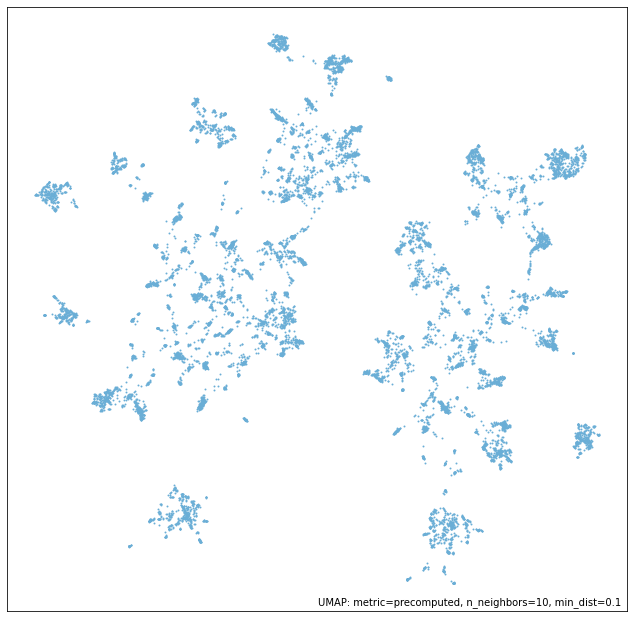

In [50]:
# plt.scatter(emb[:,0], emb[:,1])
umap.plot.points(emb)

In [51]:
emb.embedding_

array([[10.220283  , 11.581946  ],
       [12.51263   ,  8.493457  ],
       [-6.0339217 , 12.55506   ],
       ...,
       [ 8.802822  , -2.5844333 ],
       [-0.17773317, 15.436536  ],
       [-0.47611573, 15.364663  ]], shape=(13227, 2), dtype=float32)

In [2]:
df = get_data()
df_2016 = df[df['year'] == '2016/17']
umap_emb = GenerateUmapEmb(df_2016).fit_umap()

c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['active'] = df['MEMS7_ALL'] >= 150
c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LOG_MEMS7_ALL'] = np.log1p(df['MEMS7_ALL'])


DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'MEMS7_ALL',
       'LOG_MEMS7_ALL', 'active', 'Educ6', 'IMD10', 'nchild', 'nadult',
       'WorkStat10', 'VolAny', 'Motiva_POP', 'motivd_POP', 'HHLiv12', 'year',
       'LA_2023', 'LondInOut'],
      dtype='str')
>>> Shape (80820, 20)
Categorical Columns for UMAP:
 ['Gend3', 'Disab3', 'Eth7', 'WorkStat10', 'HHLiv12']
Continuous Columns for UMAP
['Age9', 'NSSEC5', 'Educ6', 'IMD10', 'nchild', 'Motiva_POP', 'motivd_POP']
Continuous Shape: (13227, 7)
Categorical Shape: (13227, 34)
Finished fitting continuous....


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1887: UserWarning: gradient function is not yet implemented for dice distance metric; inverse_transform will be unavailable
  warn(


Finished fitting categorical....
Finished computing intersection...
UMAP fit complete!


c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\plot.py:450: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax.scatter(points[:, 0], points[:, 1], s=point_size, c=color)


<Axes: >

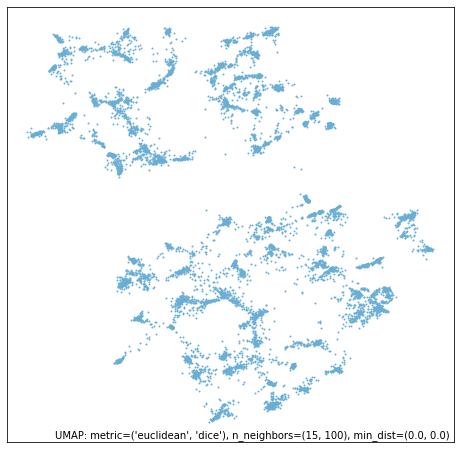

In [3]:
umap.plot.points(umap_emb)

In [ ]:
cluster_df = hdb_dbcv(emb)

100%|██████████| 11/11 [01:06<00:00,  6.00s/it]

Optimal HDBSCAN Hyperparameters:
>>>{'min_samples': 90, 'min_cluster_size': 50, 'cluster_selection_method': 'eom', 'metric': 'euclidean', 'num_clusters': 32, 'unclustered_prop': 0.08573372646858698, 'dbcv': np.float64(0.4180862998251749)}
     min_sample  min_cluster cluster_selection          m  num_clusters  \
360          90           50               eom  euclidean            32   
432         100          450               eom  euclidean             9   
364          90          100               eom  euclidean            31   
94           20          200              leaf  euclidean            30   
44           10          100               eom  euclidean            34   

     unclustered_prop      dbcv  
360          0.085734  0.418086  
432          0.031980  0.404869  
364          0.078854  0.404828  
94           0.073486  0.399930  
44           0.004461  0.395714  


In [ ]:
cluster = hdbscan.HDBSCAN(min_cluster_size = 250, min_samples = 40)
labels = cluster.fit_predict(emb)
print(len((set(labels))))

23


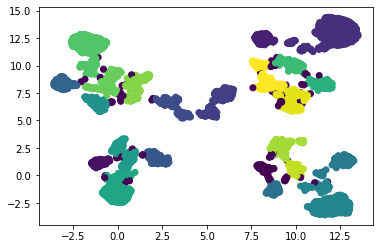

In [ ]:
plt.scatter(emb[:,0], emb[:,1], c=labels)

In [ ]:
df_2016_clean['labels'] = labels

In [ ]:
eth = df_2016_clean.groupby(['labels', 'Eth7'])['Eth7'].sum()

In [ ]:
heat = pd.crosstab(df_2016_clean['labels'], df_2016_clean['Eth7'], normalize='index')

In [ ]:
heat

Eth7,1.0,2.0,3.0,4.0,5.0,6.0,7.0
labels,,,,,,,
-1,0.548872,0.127820,0.055138,0.190476,0.030075,0.010025,0.037594
0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,0.878194,0.000000,0.000594,0.000594,0.032680,0.043969,0.043969
3,0.372549,0.100000,0.252941,0.150980,0.011765,0.072549,0.039216
4,0.307910,0.189266,0.180791,0.112994,0.098870,0.076271,0.033898
5,0.656766,0.178218,0.059406,0.046205,0.006601,0.026403,0.026403
6,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000


In [ ]:
ethnic_dist = df_2016_clean['Eth7'].value_counts(normalize=True)

In [ ]:
ethnic_dist

Eth7
1.0    0.564603
2.0    0.166629
3.0    0.124064
4.0    0.066077
6.0    0.031678
7.0    0.026234
5.0    0.020715
Name: proportion, dtype: float64

In [ ]:
overall = heat / ethnic_dist # have scaled the df for obs by ethinic pop

In [ ]:
overall

Eth7,1.0,2.0,3.0,4.0,5.0,6.0,7.0
labels,,,,,,,
-1,0.972139,0.767091,0.444429,2.882641,1.451841,0.316471,1.433013
0,0.000000,6.001361,0.000000,0.000000,0.000000,0.000000,0.000000
1,0.000000,6.001361,0.000000,0.000000,0.000000,0.000000,0.000000
2,1.555419,0.000000,0.004789,0.008992,1.577573,1.388017,1.676021
3,0.659843,0.600136,2.038789,2.284917,0.567926,2.290229,1.494830
4,0.545356,1.135851,1.457235,1.710042,4.772826,2.407730,1.292141
5,1.163235,1.069550,0.478831,0.699255,0.318638,0.833479,1.006420
6,0.000000,6.001361,0.000000,0.000000,0.000000,0.000000,0.000000
7,0.000000,6.001361,0.000000,0.000000,0.000000,0.000000,0.000000


<Axes: xlabel='Eth7', ylabel='labels'>

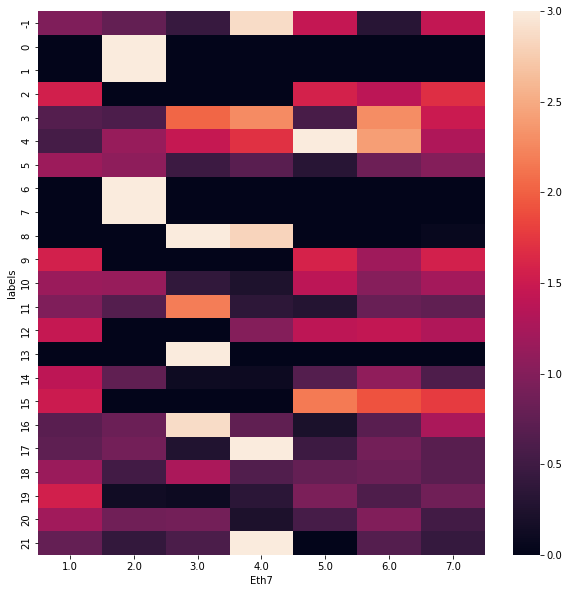

In [ ]:
plt.figure(figsize=(10,10))
sns.heatmap(
    overall,
    xticklabels = heat.columns,
    yticklabels = heat.index,
    vmax=3
)

In [ ]:
df_2016_clean['MEMS7_ALL'] = np.log1p(mems) # applied log transformation to mems to protect against skewed dist
df_2016_clean.columns

Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'LOG_MEMS7_ALL', 'Educ6',
       'IMD10', 'nchild', 'nadult', 'WorkStat10', 'VolAny', 'Motiva_POP',
       'motivd_POP', 'HHLiv12', 'LA_2023', 'LondInOut', 'labels', 'MEMS7_ALL'],
      dtype='str')

In [ ]:
cluster_profiles = df_2016_clean.groupby('labels').agg({
    'Gend3' : 'mean',
    'Disab3' : 'mean',
    'Age9' : 'mean',
    'NSSEC5' : 'mean',
    'Educ6' : 'mean',
    'IMD10' : 'mean',
    'nchild' : 'mean',
    'WorkStat10' : 'mean',
    'Motiva_POP' : 'mean',
    'motivb_POP' : 'mean',
    'motivc_POP' : 'mean',
    'motivd_POP' : 'mean',
    'VolAny' : 'mean'
    'MEMS7_ALL' : 'mean'
})

SyntaxError: invalid syntax (2652683680.py, line 15)

<Axes: >

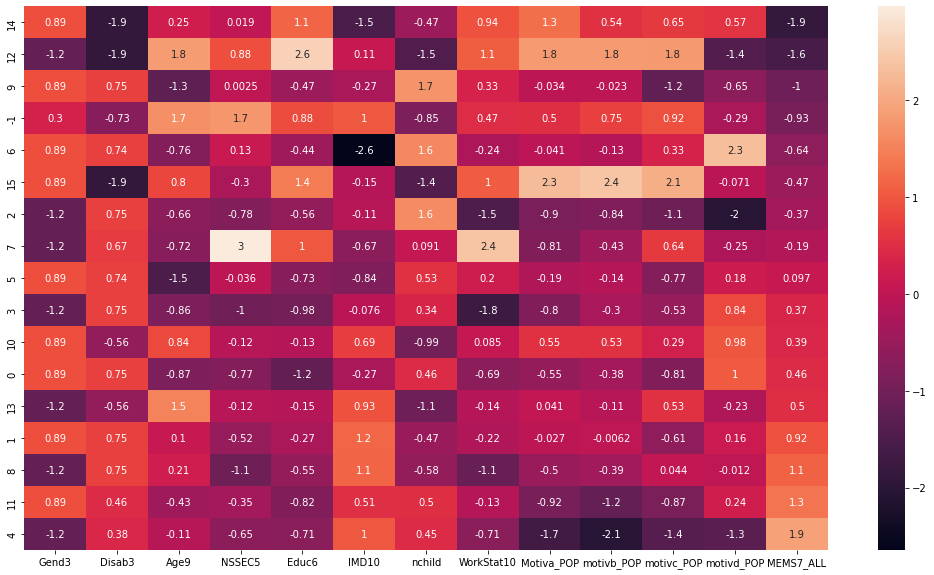

In [ ]:
scaler = StandardScaler()
sorted_cluster_profiles = cluster_profiles.sort_values('MEMS7_ALL')
heat = scaler.fit_transform(sorted_cluster_profiles)
plt.figure(figsize=(18,10))
sns.heatmap(
    heat, 
    annot=True,
    xticklabels = sorted_cluster_profiles.columns,
    yticklabels = sorted_cluster_profiles.index
)

c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:15: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['active'] = df['MEMS7_ALL'] >= 150
c:\Users\fergu\Documents\GitHub\london_sport2\src\loading_data\load_data.py:17: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['LOG_MEMS7_ALL'] = np.log1p(df['MEMS7_ALL'])


DataFrame Cleaned Successfully...
DataFrame Information:
>>> Columns:
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'MEMS7_ALL',
       'LOG_MEMS7_ALL', 'active', 'Educ6', 'IMD10', 'nchild', 'nadult',
       'WorkStat10', 'VolAny', 'Motiva_POP', 'motivd_POP', 'HHLiv12', 'year',
       'LA_2023', 'LondInOut'],
      dtype='str')
>>> Shape (80820, 20)
These are the cluster vars: ['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild', 'WorkStat10', 'Motiva_POP', 'motivd_POP', 'HHLiv12', 'year']
2016/17
['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild', 'WorkStat10', 'Motiva_POP', 'motivd_POP', 'HHLiv12']
Index(['Gend3', 'Disab3', 'Age9', 'Eth7', 'NSSEC5', 'Educ6', 'IMD10', 'nchild',
       'WorkStat10', 'Motiva_POP', 'motivd_POP', 'HHLiv12'],
      dtype='str')
These are the clustering categoricals: ['Gend3', 'Disab3', 'Eth7', 'Educ6', 'WorkStat10', 'HHLiv12']
Categorical Variables:
0 | True | Gend3
1 | True | Disab3
2 | False | Age9
3 | True

c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\fergu\Documents\GitHub\london_sport2\.venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


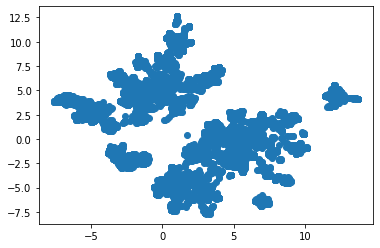

  9%|▉         | 1/11 [00:04<00:48,  4.85s/it]


KeyboardInterrupt: 

In [30]:
dc = DataCatalogue()
df = get_data()
df = df[dc.get_cluster_vars()]
print(f'These are the cluster vars: {dc.get_cluster_vars()}')
for year in sorted(list(df['year'].unique())):
    print(year)
    new = df[df['year'] == year]
    cols = [c for c in new.columns if c != 'year']
    print(cols)
    new = new[cols]
    print(new.columns)
    print(f'These are the clustering categoricals: {dc.get_clustering_categoricals()}')
    gower_matrix = get_gower(dc.get_clustering_categoricals(), new)
    emb = umap.UMAP(metric = 'precomputed', random_state = 42).fit_transform(gower_matrix)
    plt.scatter(emb[:,0], emb[:,1])
    plt.show()
    hdb = GenerateHBDSCAN(emb).hdb()
    print(len(np.unique(hdb)))
    
